# LOC Changepoint Detection\n\nComplement to IF pipeline — detects *temporal regime shifts* in KPI rates at market and hospital level.\n\n**Methods**: PELT (ruptures) + Bayesian Online Changepoint Detection (Adams & MacKay 2007)\n\n**KPIs**: initial_adr_rate, persistent_adr_rate, p2p_overturn_rate, md_escalation_rate, member_appeal_rate

In [1]:
import numpy as np
import pandas as pd
import ruptures as rpt
import matplotlib.pyplot as plt
from scipy.special import loggamma
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL

engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


## Step 1: Data Pull — Monthly KPIs by Hospital × Market

In [2]:
df_raw = pd.read_sql("""
select
    d.collection as hospital_group
    , a.fin_market
    , a.admit_act_month
    , count(distinct a.case_id) as case_count
    , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
    , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
    , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
    , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
from hce_ops_fnl.hce_adr_avtar_like_25_26_f as a
left join tmp_1y.tin_collection as d
    on substr(a.fa_prov_id, 2, 9) = d.tin
where a.fin_brand = 'M&R'
    and a.svc_setting = 'Inpatient'
    and a.admit_cat_cd in ('17 - Medical', '30 - Surgical', '33 - Transplant')
    and to_varchar(a.admit_dt_act, 'MM/dd/yyyy') is not null
    and (
        (a.global_cap = 'NA' and a.sgr_source_name = 'COSMOS'
         and a.fin_product_level_3 != 'INSTITUTIONAL' and a.tfm_include_flag = 1)
        or (a.sgr_source_name = 'NICE' and a.nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
    )
    and d.collection is not null
    and a.admit_act_month between '202501' and '202606'
group by 1, 2, 3
""", engine)

print(df_raw.shape)
df_raw.head()

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVLRbtowFP2VyHtO7AQSwAIqVsSGxFpW0krtS%2BXYDrh17Mx2SPv3cwJI3UMr7cGSZZ9zz7n33OnVWyWDIzdWaDUDcYRAwBXVTKj9DNznq3AMAuuIYkRqxWfgnVtwNZ9aUskaLxp3UHf8T8OtC3whZXH3MQONUVgTKyxWpOIWO4p3i18bnEQIE2u5cV4OnCnMCq91cK7GELZtG7WDSJs9TBBCEE2gR3WQb%2BCDRP21Rm2001TLC%2BXN9%2FSJRAzRsJPwCK%2BwPRO%2FC3UawVcqxQlk8c8834bb210OgsWlu2utbFNxs%2BPmKCi%2Fv9ucDFjvoDnsQ39YS4h9PpDIKt2Wkrxyqqu6cb5m5G%2Bw5AxKvRd%2BUuvlDNSvgpXmpfhB12XxcODxKNfoJX0slslvsuCZPG4fN8vY1TfVKhNjCoKHS65Jl%2Bva2oavVZem808oyUI0CuNBHg9wmuI0i0YoeQLB0qcpFHE982K59xFVghptdem0kkLx3iUrUFoSSkI6Tkg4LCYsLCY0DVGZDYtslKbDJIZdZgk47Q3ujZj5%2F01jCj9yzwt44zNZL7daCvoerLSpiPs8sjiK%2BxfBwrKHYl4RIReMGW6tj05K3V4bTpzfc2caDuD8pPrvps%2F%2FAg%3D%3D&RelayState=ver%3A3-hint%3A260092213708478-ETMsDgAAAZ9bw1ieABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEE7XQck8yzygwd%2BLoVPFtPkAAACQLWfkQhoDyNpl

,hospital_group,fin_market,admit_act_month,case_count,initial_adr_cnt,persistent_adr_cnt,p2p_ovrtn_cnt,md_reviewed_cnt,member_appeal_cnt
0,Astria Health System,WA,202501,2,0,0,0,1,0
1,University Of New Mexico,CO,202603,1,0,0,0,0,0
2,Wellstar Health System,PA,202507,1,0,0,0,1,0
3,MAYO CLINIC,FL,202605,35,0,0,0,0,0
4,MEDSTAR,GA,202508,1,1,1,0,1,0


In [3]:
# Market-level aggregate
df_market = (
    df_raw
    .groupby(["fin_market", "admit_act_month"], as_index = False)
    .agg(
        case_count = ("case_count", "sum"),
        initial_adr_cnt = ("initial_adr_cnt", "sum"),
        persistent_adr_cnt = ("persistent_adr_cnt", "sum"),
        p2p_ovrtn_cnt = ("p2p_ovrtn_cnt", "sum"),
        md_reviewed_cnt = ("md_reviewed_cnt", "sum"),
        member_appeal_cnt = ("member_appeal_cnt", "sum")
    )
    .assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        md_escalation_rate = lambda x: x.md_reviewed_cnt / x.case_count,
        member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt.replace(0, np.nan)
    )
    .sort_values(["fin_market", "admit_act_month"])
)

# Hospital-level with >= 10 avg monthly cases filter
hospital_avg = df_raw.groupby("hospital_group")["case_count"].mean()
valid_hospitals = hospital_avg[hospital_avg >= 10].index

df_hospital = (
    df_raw
    .query("hospital_group in @valid_hospitals")
    .assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        md_escalation_rate = lambda x: x.md_reviewed_cnt / x.case_count,
        member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt.replace(0, np.nan)
    )
    .sort_values(["hospital_group", "fin_market", "admit_act_month"])
)

print(f"Market df: {df_market.shape}, {df_market.fin_market.nunique()} markets")
print(f"Hospital df: {df_hospital.shape}, {df_hospital.hospital_group.nunique()} hospitals (>= 10 avg monthly cases)")
print(f"Months: {df_market.admit_act_month.min()} to {df_market.admit_act_month.max()}")

Market df: (964, 13), 54 markets
Hospital df: (46669, 14), 673 hospitals (>= 10 avg monthly cases)
Months: 202501 to 202606


In [10]:
df_bocd_market

""


## Step 2: PELT Changepoint Detection — Market Level

In [4]:
KPIS = ["initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate", "md_escalation_rate", "member_appeal_rate"]

def detect_changepoints_pelt(signal, pen_factor = 1.0):
    """PELT with RBF kernel and BIC-derived penalty."""
    signal = np.array(signal, dtype = float)
    signal = signal[~np.isnan(signal)]
    n = len(signal)
    if n < 6:
        return []
    model = rpt.Pelt(model = "rbf", min_size = 3, jump = 1)
    model.fit(signal.reshape(-1, 1))
    pen = pen_factor * np.log(n) * np.var(signal)
    if pen == 0:
        return []
    breakpoints = model.predict(pen = pen)
    return breakpoints[:-1]  # last element is always n


# Run PELT on each market × KPI
pelt_results = []
months_sorted = sorted(df_market["admit_act_month"].unique())

for market in df_market["fin_market"].unique():
    mkt_df = df_market.query("fin_market == @market").sort_values("admit_act_month")
    for kpi in KPIS:
        signal = mkt_df[kpi].values
        bkpts = detect_changepoints_pelt(signal)
        for bp in bkpts:
            cp_month = months_sorted[bp] if bp < len(months_sorted) else months_sorted[-1]
            pre_mean = np.nanmean(signal[:bp])
            post_mean = np.nanmean(signal[bp:])
            magnitude = (post_mean - pre_mean) / pre_mean * 100 if pre_mean != 0 else np.nan
            pelt_results.append({
                "fin_market": market,
                "kpi": kpi,
                "changepoint_idx": bp,
                "changepoint_month": cp_month,
                "pre_mean": round(pre_mean, 4),
                "post_mean": round(post_mean, 4),
                "direction": "up" if post_mean > pre_mean else "down",
                "magnitude_pct": round(magnitude, 1)
            })

df_pelt_market = pd.DataFrame(pelt_results)
print(f"PELT detected {len(df_pelt_market)} changepoints across {df_pelt_market.fin_market.nunique()} markets")
df_pelt_market.head(10)

PELT detected 1125 changepoints across 54 markets


,fin_market,kpi,changepoint_idx,changepoint_month,pre_mean,post_mean,direction,magnitude_pct
0,AK,initial_adr_rate,3,202504,0.2063,0.0661,down,-68.0
1,AK,initial_adr_rate,6,202507,0.1310,0.0687,down,-47.5
2,AK,initial_adr_rate,9,202510,0.1305,0.0484,down,-62.9
3,AK,initial_adr_rate,12,202601,0.1130,0.0423,down,-62.6
4,AK,initial_adr_rate,15,202604,0.1074,0.0000,down,-100.0
5,AK,persistent_adr_rate,3,202504,0.0794,0.0209,down,-73.7
6,AK,persistent_adr_rate,6,202507,0.0397,0.0261,down,-34.2
7,AK,persistent_adr_rate,9,202510,0.0388,0.0224,down,-42.1
8,AK,persistent_adr_rate,12,202601,0.0367,0.0185,down,-49.5
9,AK,persistent_adr_rate,15,202604,0.0367,0.0000,down,-100.0


## Step 3: Bayesian Online Changepoint Detection — Market Level\n\nAdams & MacKay (2007) with Normal-Inverse-Gamma conjugate prior.

In [17]:
def bocd(data, hazard_lambda=12, threshold=0.5):
    """
    Bayesian Online Changepoint Detection (Adams & MacKay 2007).
    Normal-Inverse-Gamma observation model, constant hazard.
    Detects changepoints where cumulative P(run_length < threshold_rl) spikes,
    indicating the posterior believes a recent restart is more likely than
    continuation of the current regime.
    """
    data = np.array(data, dtype=float)
    data = data[~np.isnan(data)]
    n = len(data)
    if n < 6:
        return []

    # Hyperpriors (weakly informative)
    mu0 = np.nanmean(data)
    kappa0 = 1.0
    alpha0 = 1.0
    beta0 = np.nanvar(data) * alpha0 if np.nanvar(data) > 0 else 0.01

    # Hazard: constant 1/lambda
    H = 1.0 / hazard_lambda

    # Run-length posterior: R[r] = P(run_length = r) at current timestep
    R = np.array([1.0])

    # Sufficient statistics for each run length
    mu = np.array([mu0])
    kappa = np.array([kappa0])
    alpha = np.array([alpha0])
    beta = np.array([beta0])

    # Track MAP run length over time for changepoint detection
    map_rl = np.zeros(n, dtype=int)

    for t in range(n):
        x = data[t]

        # Predictive probability: Student-t
        df = 2 * alpha
        scale = beta * (kappa + 1) / (kappa * alpha)
        pred_prob = np.exp(
            loggamma((df + 1) / 2) - loggamma(df / 2)
            - 0.5 * np.log(np.pi * df * scale)
            - (df + 1) / 2 * np.log(1 + (x - mu) ** 2 / (df * scale))
        )

        # Growth probabilities
        R_new = np.zeros(len(R) + 1)
        R_new[1:] = R * pred_prob * (1 - H)

        # Changepoint probability
        R_new[0] = np.sum(R * pred_prob * H)

        # Normalize
        evidence = R_new.sum()
        if evidence > 0:
            R_new /= evidence

        R = R_new
        map_rl[t] = np.argmax(R)

        # Update sufficient statistics
        mu_new = np.concatenate([[mu0], (kappa * mu + x) / (kappa + 1)])
        kappa_new = np.concatenate([[kappa0], kappa + 1])
        alpha_new = np.concatenate([[alpha0], alpha + 0.5])
        beta_new = np.concatenate([[beta0], beta + kappa * (x - mu) ** 2 / (2 * (kappa + 1))])

        mu = mu_new
        kappa = kappa_new
        alpha = alpha_new
        beta = beta_new

    # Detect changepoints: MAP run length drops sharply (resets to short run)
    changepoints = []
    for t in range(2, n):
        if map_rl[t] < map_rl[t - 1] and map_rl[t] <= 1:
            changepoints.append(t)

    return changepoints


# Run BOCD on each market × KPI
bocd_results = []

for market in df_market["fin_market"].unique():
    mkt_df = df_market.query("fin_market == @market").sort_values("admit_act_month")
    for kpi in KPIS:
        signal = mkt_df[kpi].values
        cps = bocd(signal)
        for cp in cps:
            cp_month = months_sorted[cp] if cp < len(months_sorted) else months_sorted[-1]
            pre_mean = np.nanmean(signal[:cp])
            post_mean = np.nanmean(signal[cp:])
            magnitude = (post_mean - pre_mean) / pre_mean * 100 if pre_mean != 0 else np.nan
            bocd_results.append({
                "fin_market": market,
                "kpi": kpi,
                "changepoint_idx": cp,
                "changepoint_month": cp_month,
                "pre_mean": round(pre_mean, 4),
                "post_mean": round(post_mean, 4),
                "direction": "up" if post_mean > pre_mean else "down",
                "magnitude_pct": round(magnitude, 1)
            })

df_bocd_market = pd.DataFrame(bocd_results)
if df_bocd_market.empty:
    print("BOCD detected 0 changepoints")
else:
    print(f"BOCD detected {len(df_bocd_market)} changepoints across {df_bocd_market.fin_market.nunique()} markets")

BOCD detected 81 changepoints across 46 markets


In [18]:
# Concordance: both methods agree within +/- 1 month
concordance_records = []
for market in df_market["fin_market"].unique():
    for kpi in KPIS:
        pelt_cps = set(df_pelt_market.query("fin_market == @market and kpi == @kpi")["changepoint_idx"])
        bocd_cps = set(df_bocd_market.query("fin_market == @market and kpi == @kpi")["changepoint_idx"])
        for p in pelt_cps:
            matched = any(abs(p - b) <= 1 for b in bocd_cps)
            concordance_records.append({"fin_market": market, "kpi": kpi, "pelt_idx": p, "concordant": matched})

df_concordance = pd.DataFrame(concordance_records)
if len(df_concordance) > 0:
    rate = df_concordance["concordant"].mean() * 100
    print(f"PELT-BOCD concordance rate: {rate:.1f}% ({df_concordance['concordant'].sum()}/{len(df_concordance)} PELT changepoints confirmed by BOCD)")
else:
    print("No PELT changepoints to compare.")

PELT-BOCD concordance rate: 6.0% (68/1125 PELT changepoints confirmed by BOCD)


## Step 4: Market-Level Visualization\n\nFaceted panels: 5 KPIs per market, with PELT (red) and BOCD (blue) changepoints marked.

Plotting top 10 markets by changepoint count:
fin_market
IL      27
OK      26
WY      26
NY      25
DC      25
CA-S    25
NV      25
SC      25
WV      25
LA      24
dtype: int64


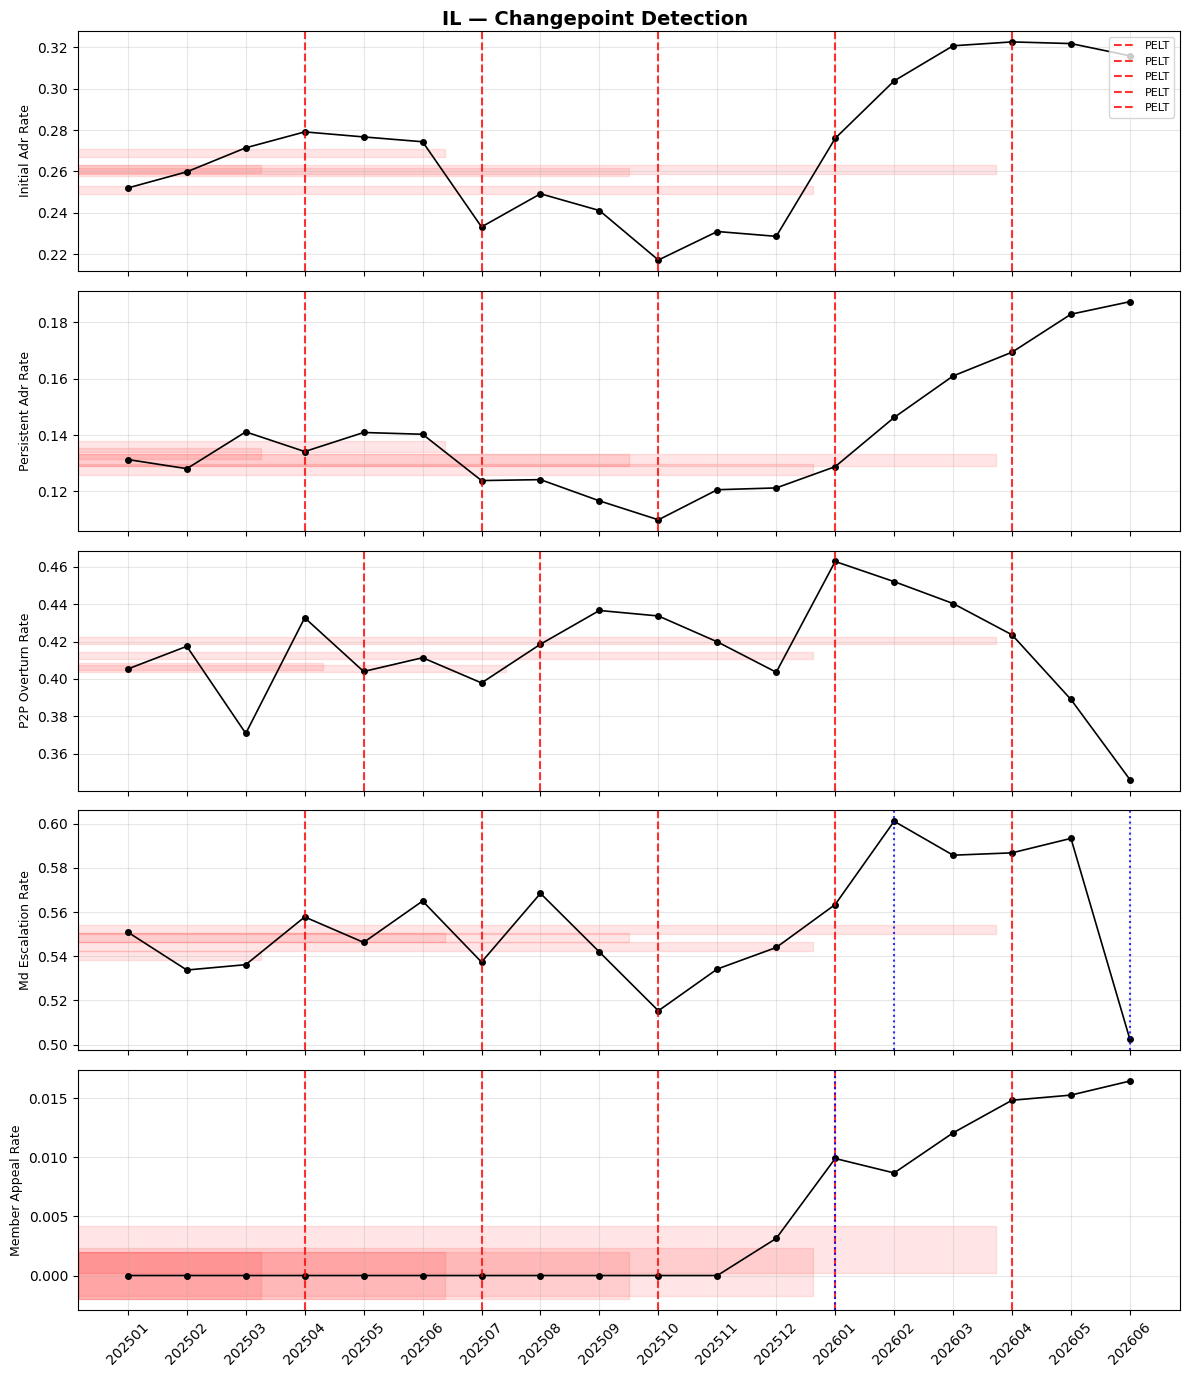

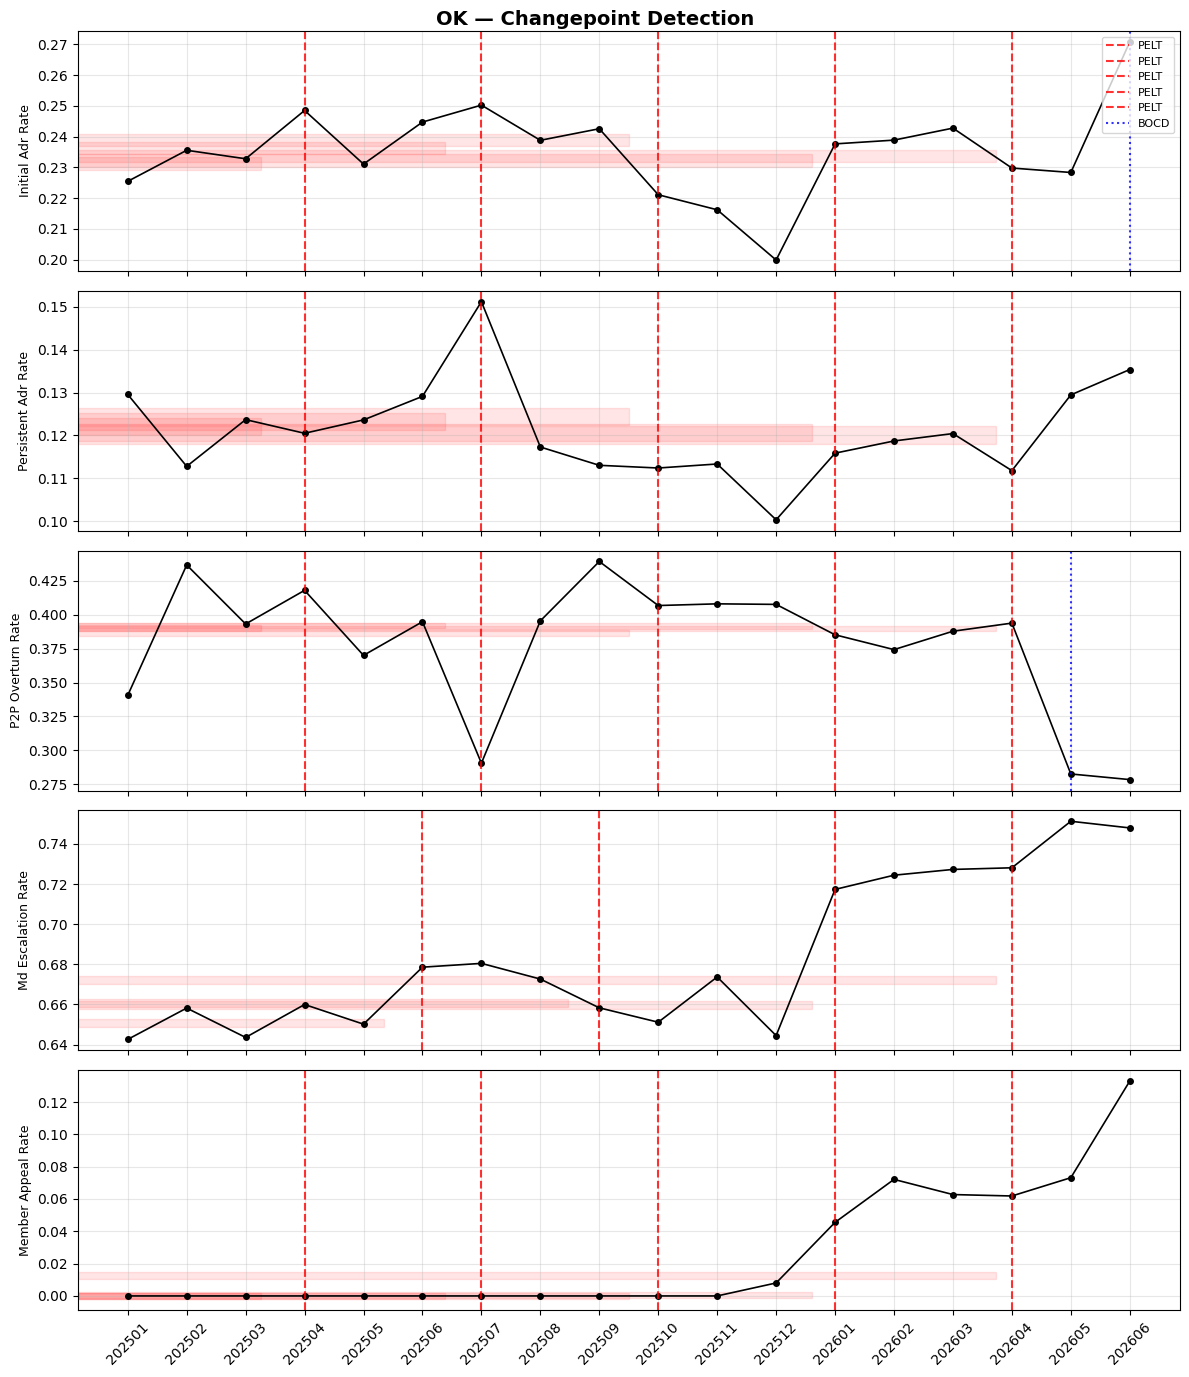

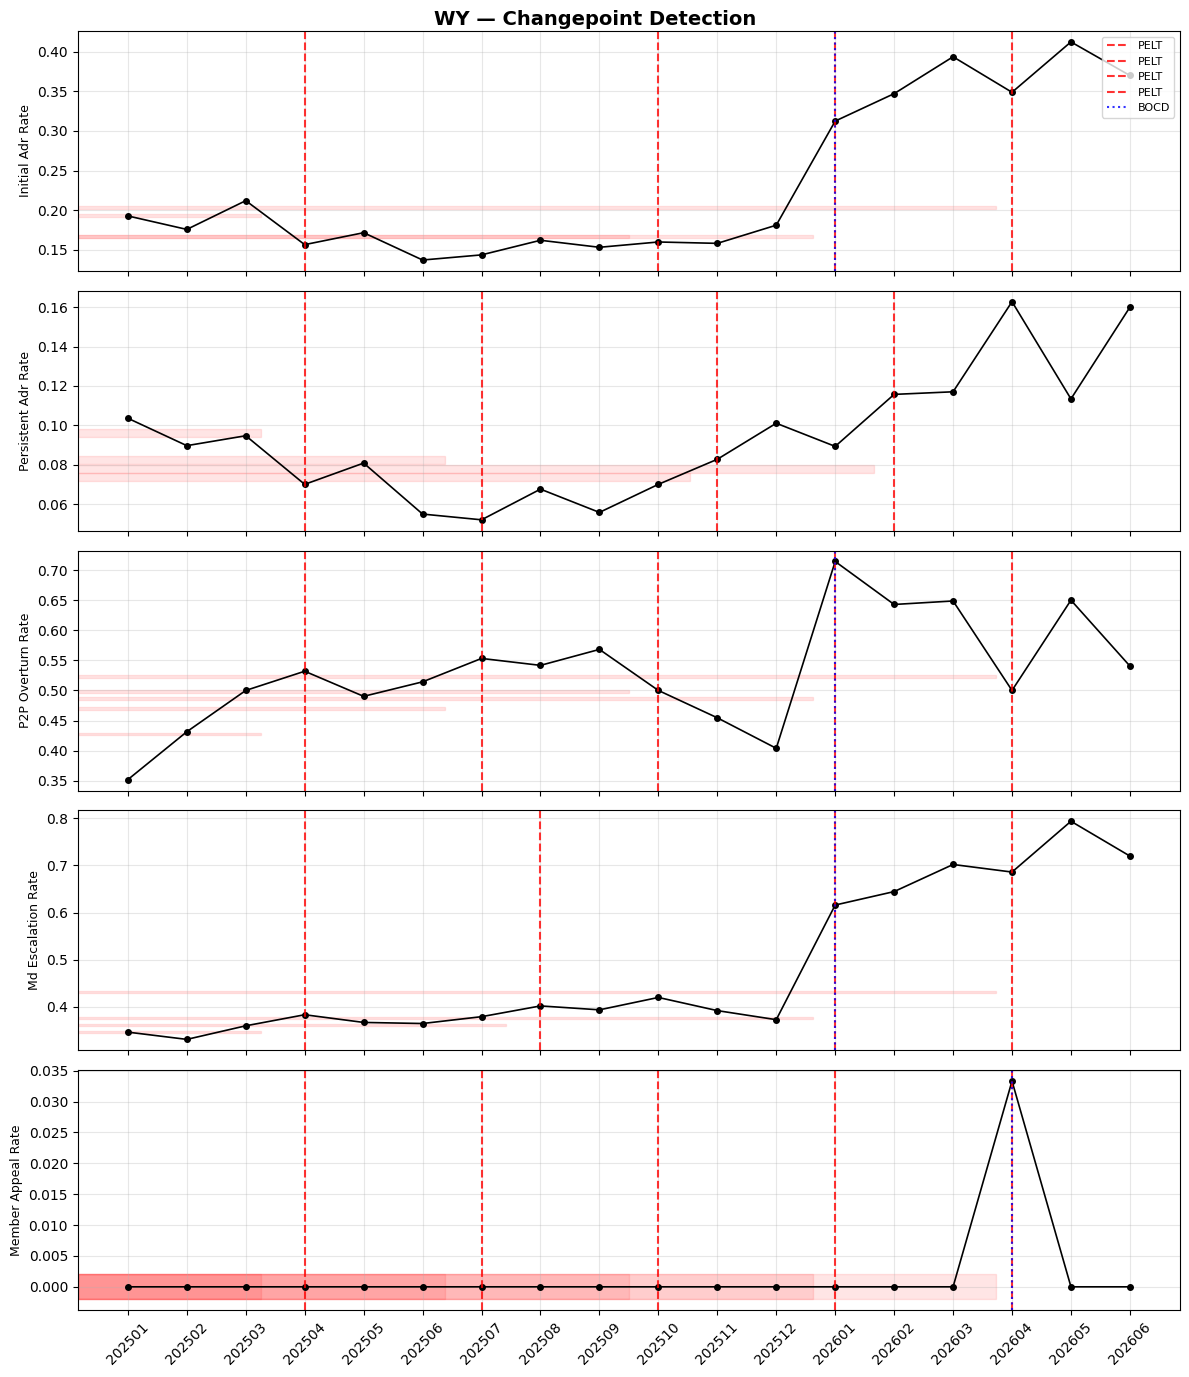

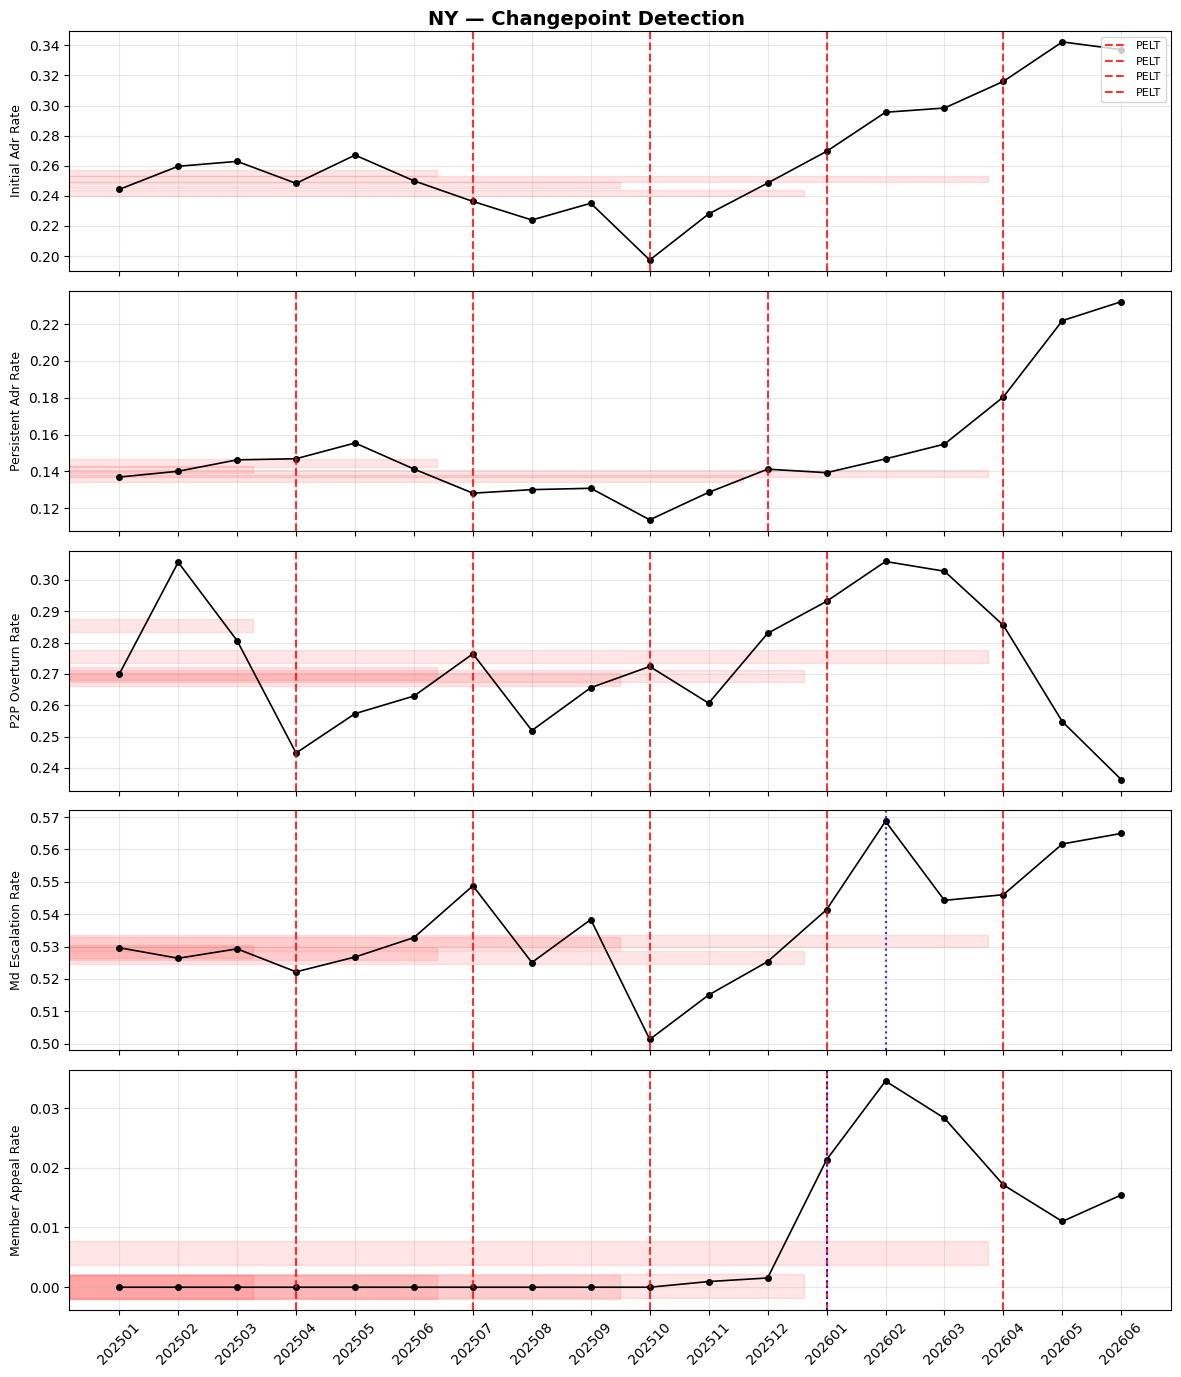

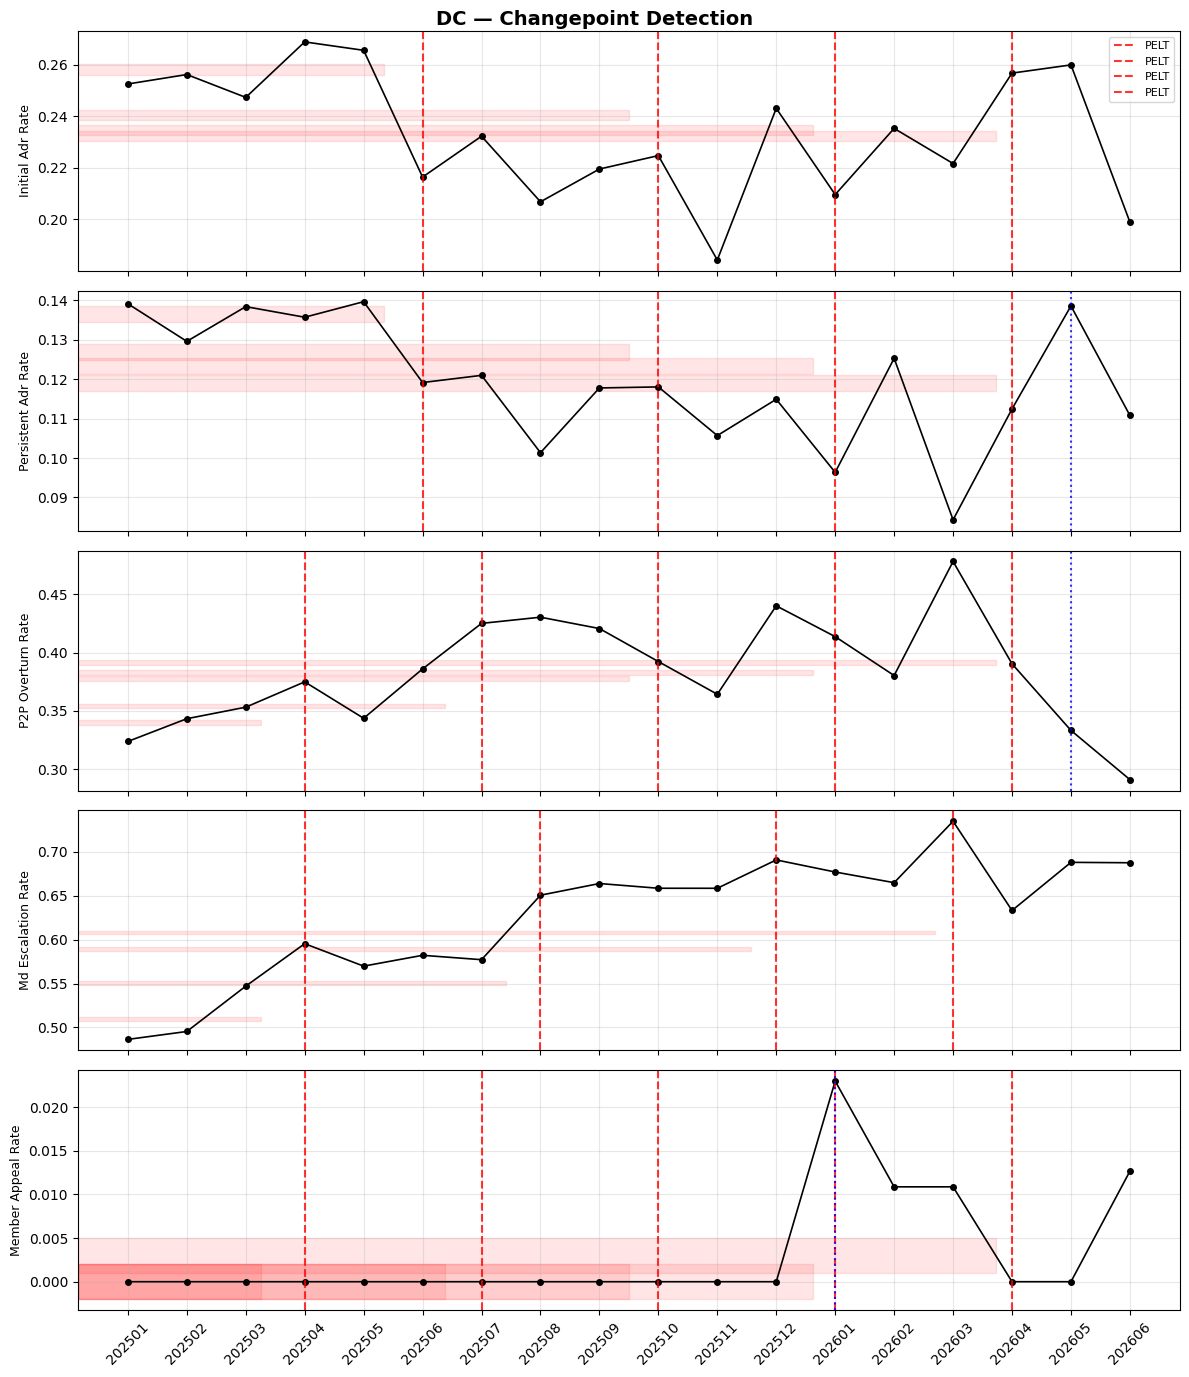

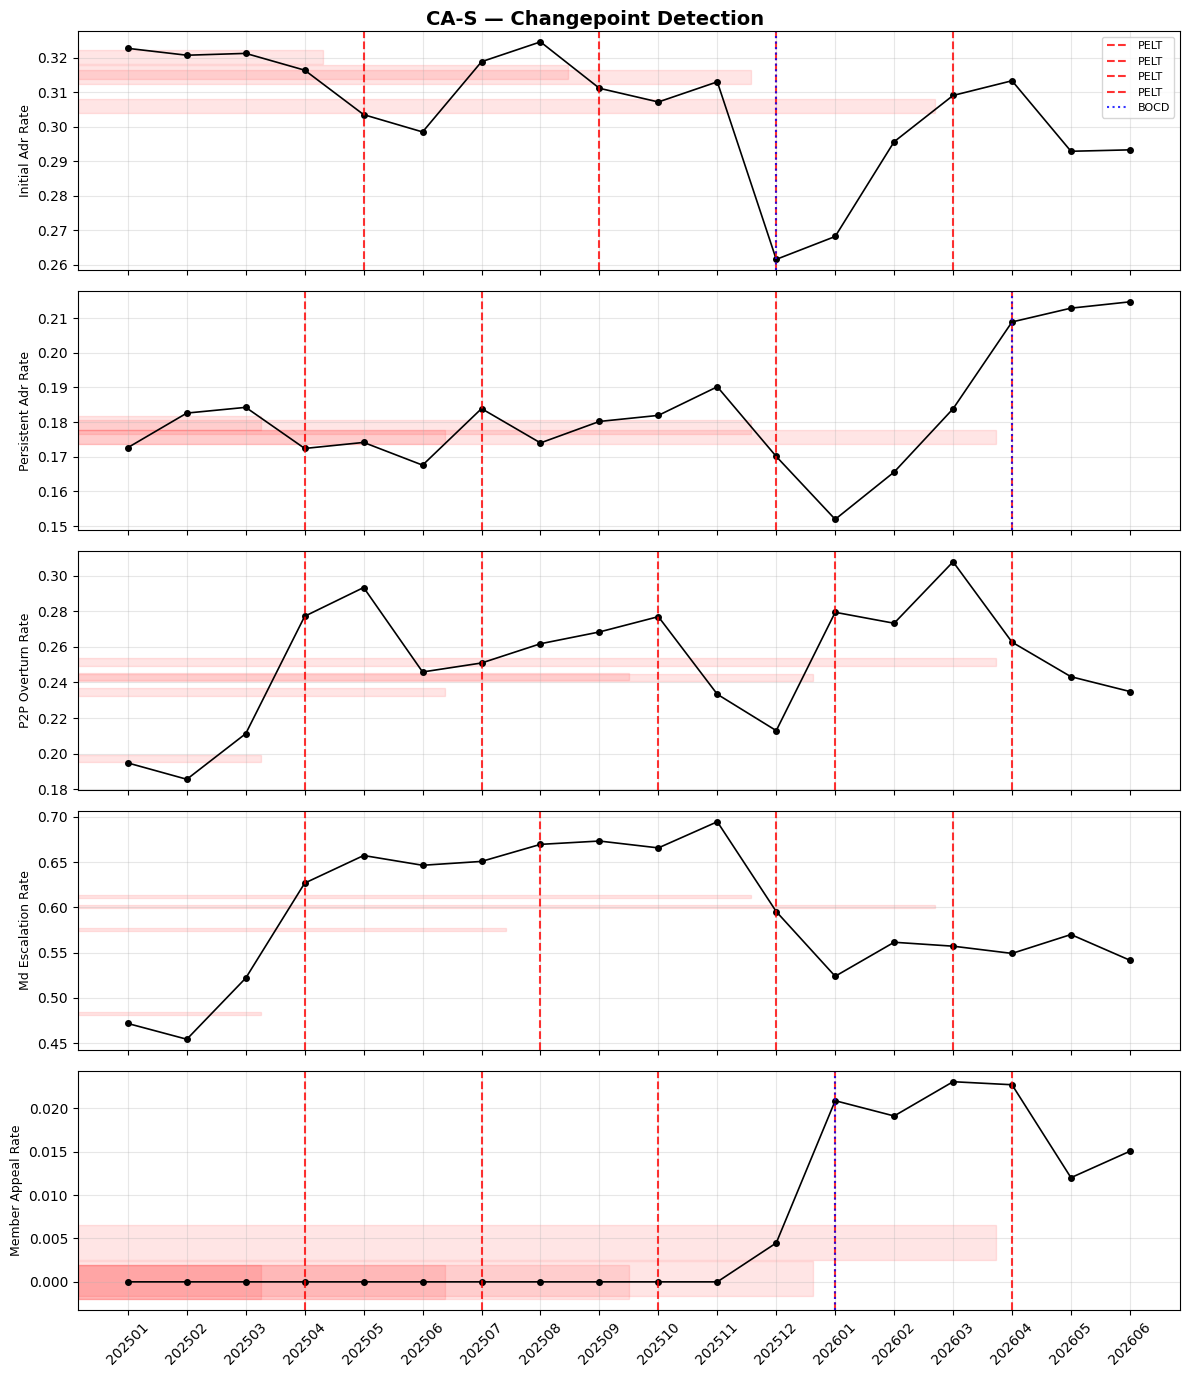

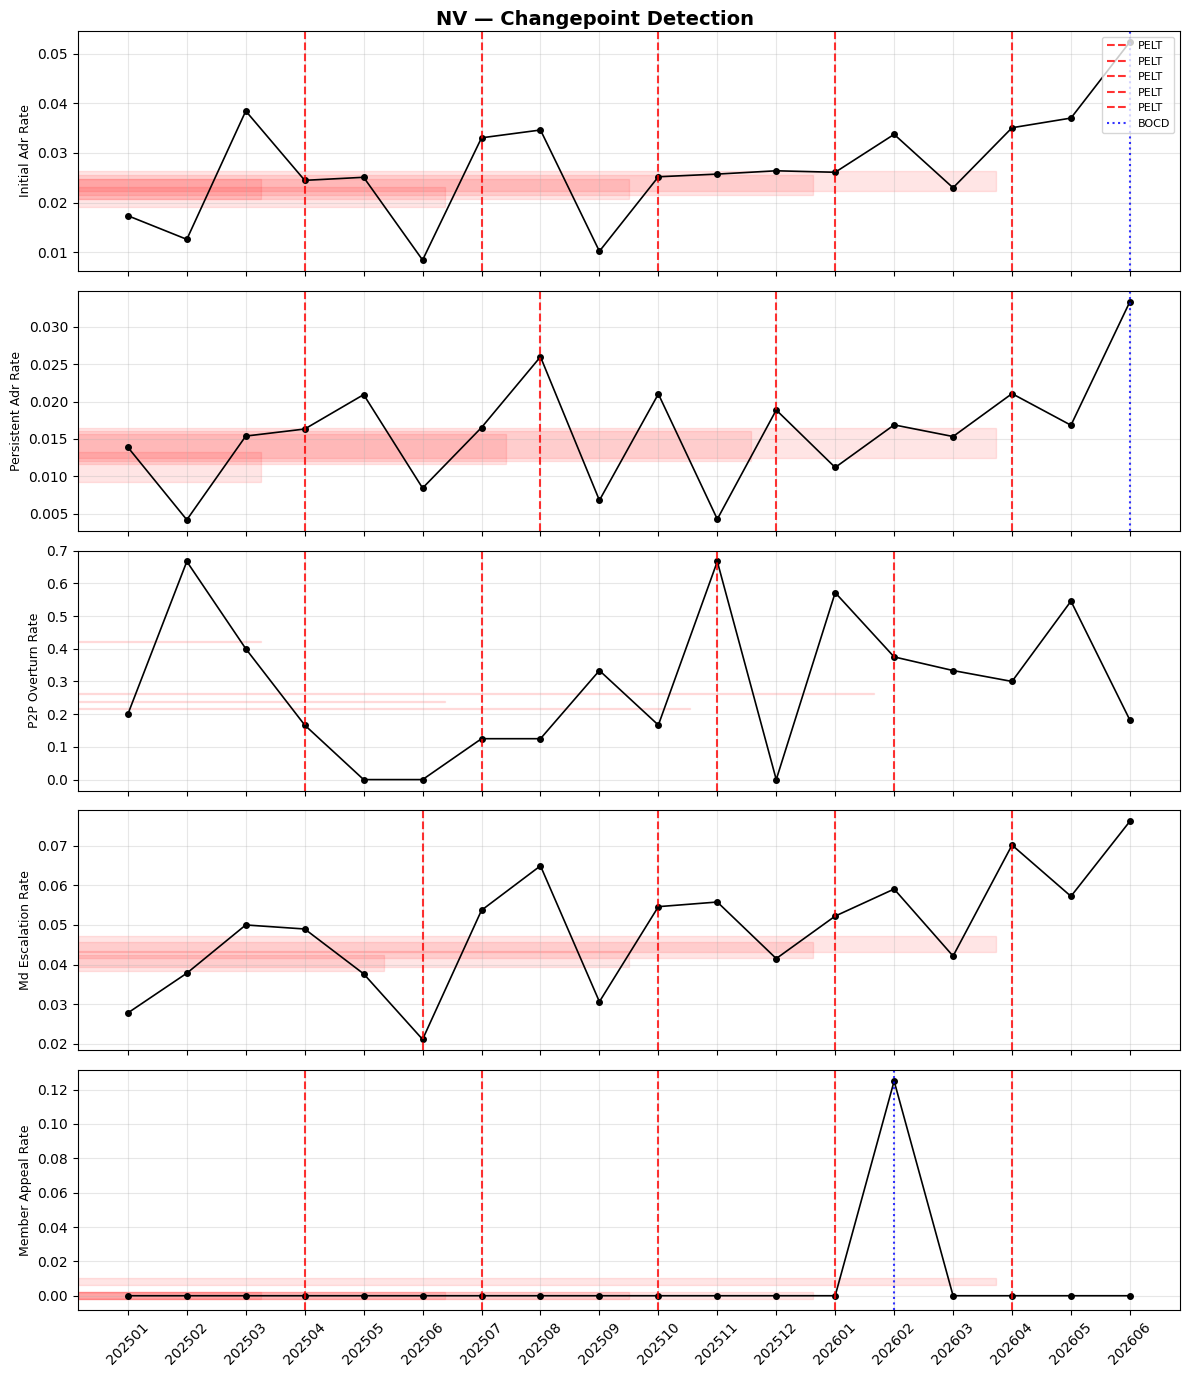

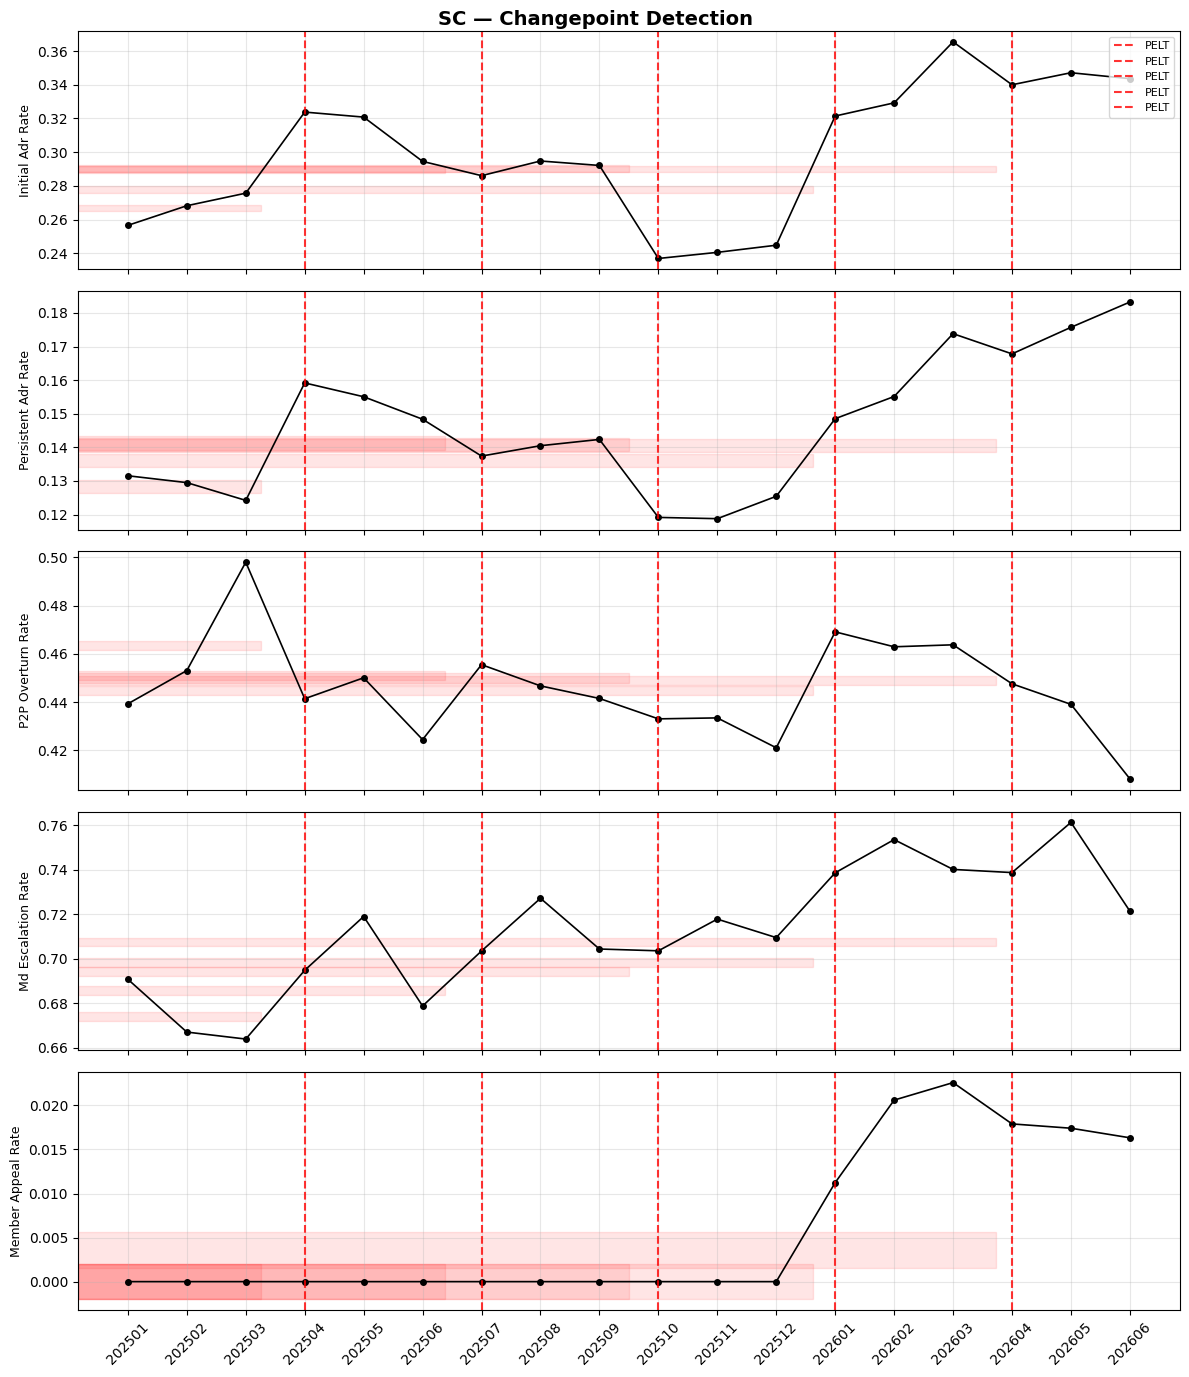

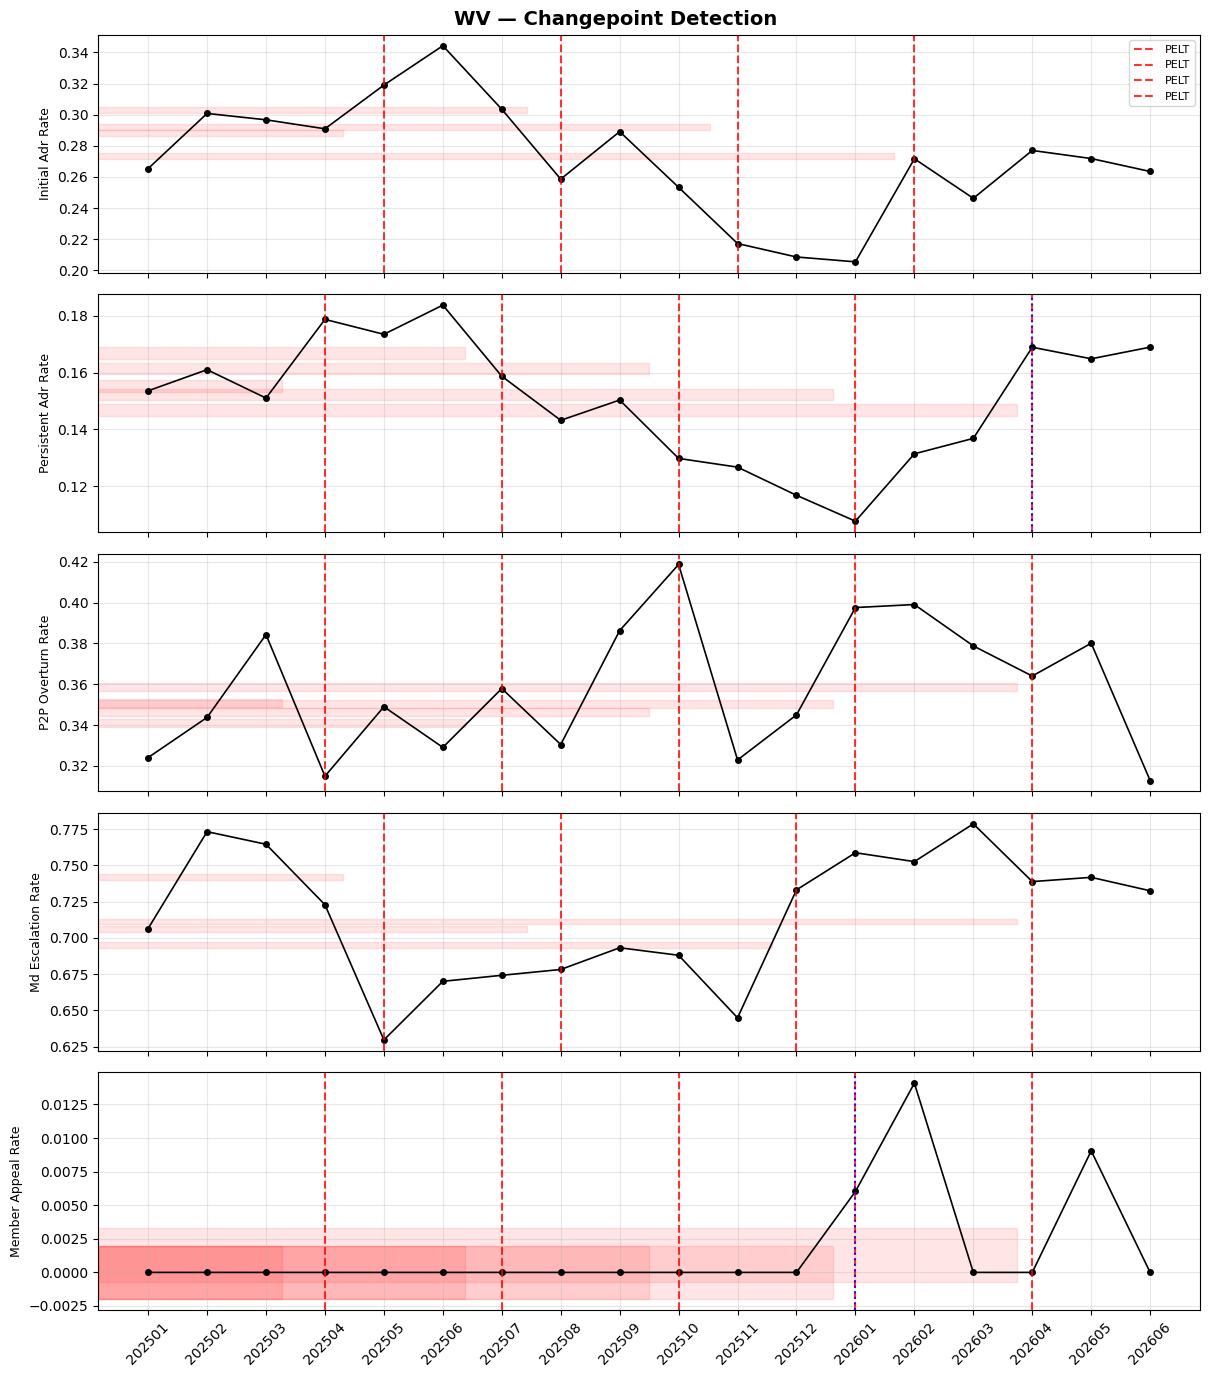

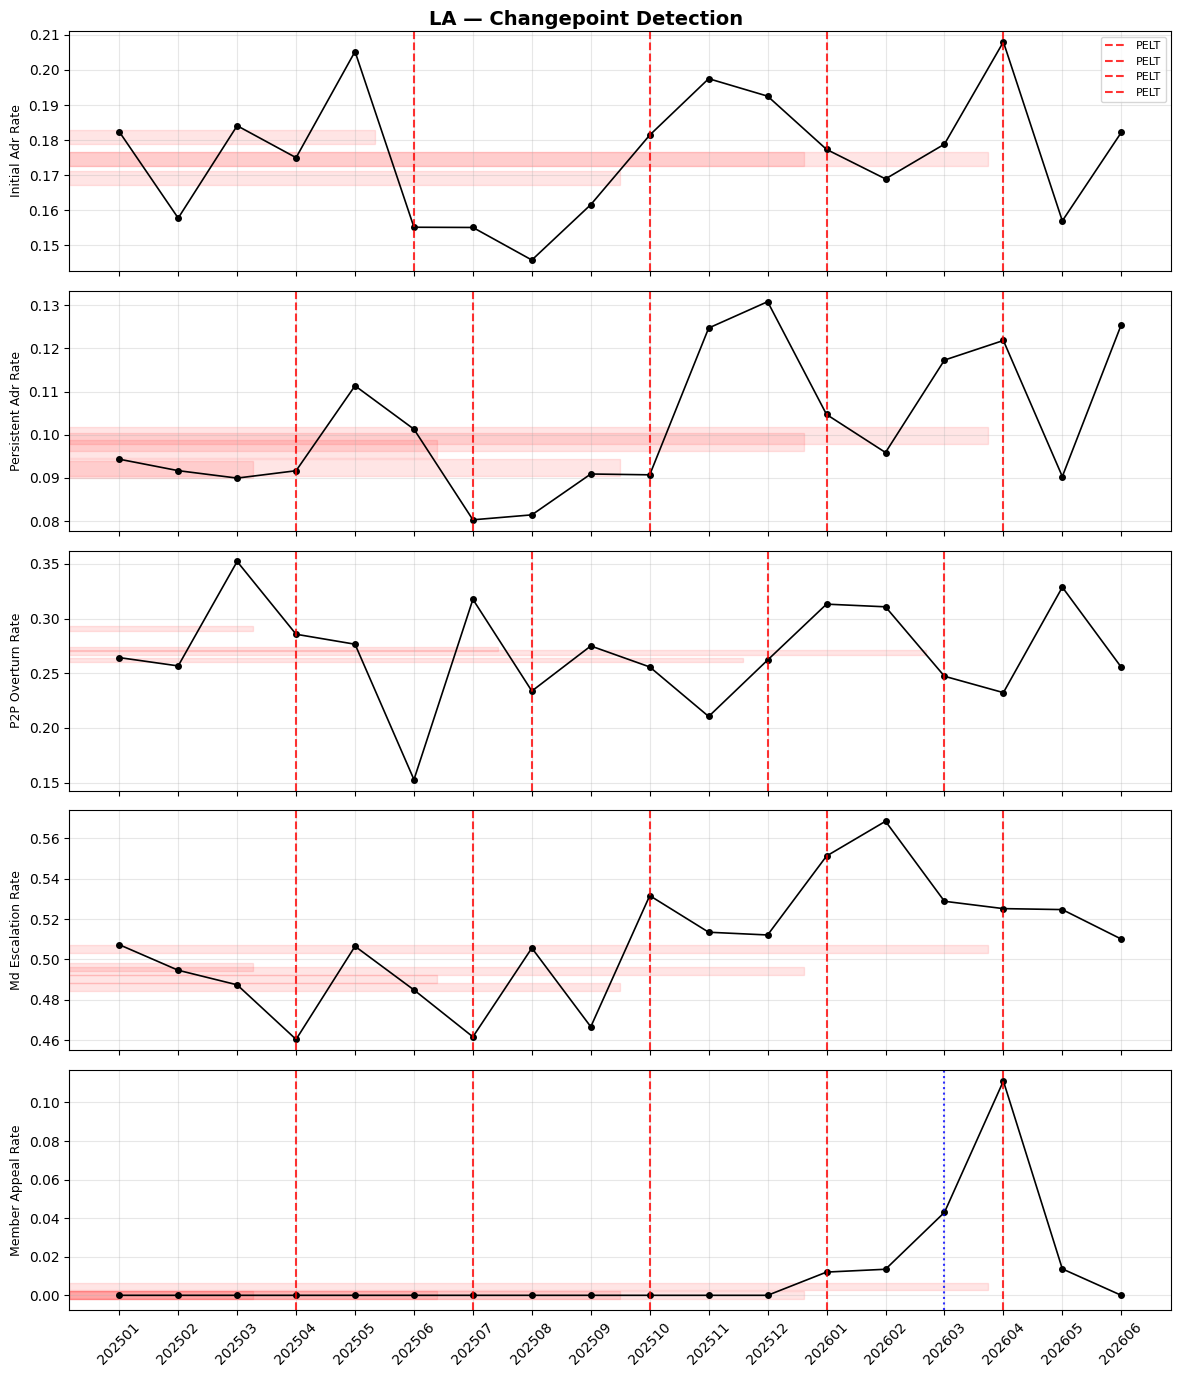

In [19]:
def plot_market_changepoints(market, df_mkt, pelt_df, bocd_df, months):
    """Faceted panel for one market: 5 KPIs with changepoint markers."""
    fig, axes = plt.subplots(5, 1, figsize = (12, 14), sharex = True)
    fig.suptitle(f"{market} — Changepoint Detection", fontsize = 14, fontweight = "bold")

    for i, kpi in enumerate(KPIS):
        ax = axes[i]
        series = df_mkt[kpi].values
        ax.plot(months, series, "k-o", markersize = 4, linewidth = 1.2)
        ax.set_ylabel(kpi.replace("_", " ").title(), fontsize = 9)

        # PELT changepoints (red)
        pelt_cps = pelt_df.query("fin_market == @market and kpi == @kpi")
        for _, row in pelt_cps.iterrows():
            idx = row["changepoint_idx"]
            if idx < len(months):
                ax.axvline(months[idx], color = "red", linestyle = "--", alpha = 0.8, label = "PELT" if i == 0 else "")
                # Shade pre/post means
                ax.axhspan(row["pre_mean"] - 0.002, row["pre_mean"] + 0.002,
                           xmax = idx / len(months), color = "red", alpha = 0.1)

        # BOCD changepoints (blue)
        bocd_cps = bocd_df.query("fin_market == @market and kpi == @kpi")
        for _, row in bocd_cps.iterrows():
            idx = row["changepoint_idx"]
            if idx < len(months):
                ax.axvline(months[idx], color = "blue", linestyle = ":", alpha = 0.8, label = "BOCD" if i == 0 else "")

        ax.grid(True, alpha = 0.3)

    axes[0].legend(loc = "upper right", fontsize = 8)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()


# Plot top markets by number of detected changepoints
market_cp_counts = (
    pd.concat([
        df_pelt_market[["fin_market"]].assign(method = "PELT"),
        df_bocd_market[["fin_market"]].assign(method = "BOCD")
    ])
    .groupby("fin_market").size()
    .sort_values(ascending = False)
)

# Plot top 10 markets with most changepoints
top_markets = market_cp_counts.head(10).index.tolist()
print(f"Plotting top {len(top_markets)} markets by changepoint count:")
print(market_cp_counts.head(10))

for market in top_markets:
    mkt_df = df_market.query("fin_market == @market").sort_values("admit_act_month")
    plot_market_changepoints(market, mkt_df, df_pelt_market, df_bocd_market, months_sorted)

## Step 5: Hospital-Level Detection\n\nSame PELT + BOCD pipeline with higher PELT penalty (pen_factor = 1.5) for noisier hospital series.

In [20]:
# Hospital-level PELT (higher penalty for noisy series)
pelt_hosp_results = []

for (hosp, market), grp in df_hospital.groupby(["hospital_group", "fin_market"]):
    grp = grp.sort_values("admit_act_month")
    for kpi in KPIS:
        signal = grp[kpi].values
        bkpts = detect_changepoints_pelt(signal, pen_factor = 1.5)
        for bp in bkpts:
            cp_month = months_sorted[bp] if bp < len(months_sorted) else months_sorted[-1]
            pre_mean = np.nanmean(signal[:bp])
            post_mean = np.nanmean(signal[bp:])
            magnitude = (post_mean - pre_mean) / pre_mean * 100 if pre_mean != 0 else np.nan
            pelt_hosp_results.append({
                "hospital_group": hosp,
                "fin_market": market,
                "kpi": kpi,
                "changepoint_idx": bp,
                "changepoint_month": cp_month,
                "pre_mean": round(pre_mean, 4),
                "post_mean": round(post_mean, 4),
                "direction": "up" if post_mean > pre_mean else "down",
                "magnitude_pct": round(magnitude, 1),
                "method": "PELT"
            })

# Hospital-level BOCD
bocd_hosp_results = []

for (hosp, market), grp in df_hospital.groupby(["hospital_group", "fin_market"]):
    grp = grp.sort_values("admit_act_month")
    for kpi in KPIS:
        signal = grp[kpi].values
        cps = bocd(signal)
        for cp in cps:
            cp_month = months_sorted[cp] if cp < len(months_sorted) else months_sorted[-1]
            pre_mean = np.nanmean(signal[:cp])
            post_mean = np.nanmean(signal[cp:])
            magnitude = (post_mean - pre_mean) / pre_mean * 100 if pre_mean != 0 else np.nan
            bocd_hosp_results.append({
                "hospital_group": hosp,
                "fin_market": market,
                "kpi": kpi,
                "changepoint_idx": cp,
                "changepoint_month": cp_month,
                "pre_mean": round(pre_mean, 4),
                "post_mean": round(post_mean, 4),
                "direction": "up" if post_mean > pre_mean else "down",
                "magnitude_pct": round(magnitude, 1),
                "method": "BOCD"
            })

df_hosp_cps = pd.concat([pd.DataFrame(pelt_hosp_results), pd.DataFrame(bocd_hosp_results)], ignore_index = True)

# Add concordance flag
df_hosp_cps["concordance"] = False
for (hosp, market, kpi), grp in df_hosp_cps.groupby(["hospital_group", "fin_market", "kpi"]):
    pelt_idxs = set(grp.query("method == 'PELT'")["changepoint_idx"])
    bocd_idxs = set(grp.query("method == 'BOCD'")["changepoint_idx"])
    for idx in grp.index:
        row = grp.loc[idx]
        if row["method"] == "PELT":
            df_hosp_cps.loc[idx, "concordance"] = any(abs(row["changepoint_idx"] - b) <= 1 for b in bocd_idxs)
        else:
            df_hosp_cps.loc[idx, "concordance"] = any(abs(row["changepoint_idx"] - p) <= 1 for p in pelt_idxs)

print(f"Hospital-level: {len(df_hosp_cps)} total changepoints across {df_hosp_cps.hospital_group.nunique()} hospitals")
print(f"  PELT: {len(df_hosp_cps.query('method == \"PELT\"'))}")
print(f"  BOCD: {len(df_hosp_cps.query('method == \"BOCD\"'))}")
print(f"  Concordant: {df_hosp_cps['concordance'].sum()}")

C:\Users\knguy139\AppData\Local\Temp\ipykernel_36252\1465375153.py:11: RuntimeWarning: Mean of empty slice
  pre_mean = np.nanmean(signal[:bp])


Hospital-level: 21486 total changepoints across 644 hospitals
  PELT: 19301
  BOCD: 2185
  Concordant: 2915


## Step 6: Hospital-Level Summary & Visualization

In [21]:
# Summary: hospitals ranked by total changepoints (concordant ones weighted higher)
hosp_summary = (
    df_hosp_cps
    .groupby(["hospital_group", "fin_market"])
    .agg(
        total_changepoints = ("changepoint_idx", "count"),
        concordant_cps = ("concordance", "sum"),
        kpis_affected = ("kpi", "nunique"),
        latest_cp_month = ("changepoint_month", "max")
    )
    .assign(concordant_cps = lambda x: x.concordant_cps.astype(int))
    .sort_values("concordant_cps", ascending = False)
    .reset_index()
)

print("Top 20 most volatile hospitals (by concordant changepoints):")
hosp_summary.head(20)

Top 20 most volatile hospitals (by concordant changepoints):


,hospital_group,fin_market,total_changepoints,concordant_cps,kpis_affected,latest_cp_month
0,Steward,FL,27,10,5,202606
1,TENET HEALTHCARE CORPORATION,TX,27,10,5,202605
2,Lehigh Valley Health Network,PA,25,10,5,202604
3,Albany Medical Center,NY,24,10,5,202605
4,University of Vermont Health Network,NY,22,8,5,202604
5,University of Pennsylvania,NJ,19,8,3,202605
6,UNIVERSITY OF MIAMI HOSPITAL AND CLINICS,FL,25,8,5,202605
7,TENET HEALTHCARE CORPORATION,CA-S,22,8,4,202605
8,Sentara Healthcare,VA,19,8,3,202605
9,SOUTHWEST GENERAL HEALTH CENTER,OH,27,8,5,202604




In [22]:
# Heatmap: hospitals × months, colored by # KPIs that shifted
# Use only concordant changepoints for cleaner signal
concordant_cps = df_hosp_cps.query("concordance == True and method == 'PELT'")

heatmap_data = (
    concordant_cps
    .groupby(["hospital_group", "changepoint_month"])["kpi"]
    .nunique()
    .reset_index(name = "n_kpis_shifted")
    .pivot(index = "hospital_group", columns = "changepoint_month", values = "n_kpis_shifted")
    .fillna(0)
    .astype(int)
)

# Filter to hospitals with at least 2 concordant changepoints for readability
hosp_with_multiple = hosp_summary.query("concordant_cps >= 2")["hospital_group"]
heatmap_filtered = heatmap_data.loc[heatmap_data.index.isin(hosp_with_multiple)]

if len(heatmap_filtered) > 0:
    fig, ax = plt.subplots(figsize = (14, max(6, len(heatmap_filtered) * 0.4)))
    im = ax.imshow(heatmap_filtered.values, aspect = "auto", cmap = "YlOrRd", vmin = 0, vmax = 5)
    ax.set_xticks(range(len(heatmap_filtered.columns)))
    ax.set_xticklabels(heatmap_filtered.columns, rotation = 45, ha = "right", fontsize = 8)
    ax.set_yticks(range(len(heatmap_filtered.index)))
    ax.set_yticklabels(heatmap_filtered.index, fontsize = 7)
    ax.set_xlabel("Month")
    ax.set_ylabel("Hospital Group")
    ax.set_title("Concordant Changepoints: # KPIs Shifted per Hospital × Month")
    plt.colorbar(im, ax = ax, label = "# KPIs with changepoint")
    plt.tight_layout()
    plt.show()
else:
    print("No hospitals with >= 2 concordant changepoints to plot.")

In [23]:
# Sanity check: member_appeal_rate should show changepoint at ~202601
# (didn't exist before 2026 so the rate jumps from 0)
sanity = df_pelt_market.query("kpi == 'member_appeal_rate'")
print("Sanity check — member_appeal_rate changepoints (expect ~202601):")
print(sanity[["fin_market", "changepoint_month", "pre_mean", "post_mean", "magnitude_pct"]].to_string(index = False))

engine.dispose()
print("\nDone. Engine disposed.")

Sanity check — member_appeal_rate changepoints (expect ~202601):
fin_market changepoint_month  pre_mean  post_mean  magnitude_pct
        AL            202504    0.0000     0.0062            NaN
        AL            202507    0.0000     0.0077            NaN
        AL            202510    0.0000     0.0103            NaN
        AL            202601    0.0000     0.0155            NaN
        AL            202604    0.0033     0.0143          328.8
        AR            202504    0.0000     0.0056            NaN
        AR            202507    0.0000     0.0069            NaN
        AR            202510    0.0000     0.0093            NaN
        AR            202601    0.0000     0.0139            NaN
        AR            202604    0.0032     0.0115          254.5
        AZ            202504    0.0000     0.0059            NaN
        AZ            202507    0.0000     0.0073            NaN
        AZ            202510    0.0000     0.0098            NaN
        AZ            202

In [24]:
# Top 10 markets by largest downward dip (most negative magnitude_pct)
top_dips = (
    df_bocd_market
    .query("direction == 'down'")
    .sort_values("magnitude_pct")
    .groupby("fin_market")
    .first()
    .reset_index()
    .sort_values("magnitude_pct")
    .head(10)
    [["fin_market", "kpi", "changepoint_month", "pre_mean", "post_mean", "magnitude_pct"]]
)

print("Top 10 Markets — Largest Dip (BOCD)")
top_dips

Top 10 Markets — Largest Dip (BOCD)


,fin_market,kpi,changepoint_month,pre_mean,post_mean,magnitude_pct
19,VT,p2p_overturn_rate,202601,0.4892,0.1667,-65.9
6,HI,md_escalation_rate,202602,0.6363,0.3746,-41.1
11,NC,p2p_overturn_rate,202602,0.3242,0.1992,-38.5
10,MN,p2p_overturn_rate,202606,0.3804,0.2342,-38.4
18,UT,p2p_overturn_rate,202606,0.4559,0.2903,-36.3
5,DE,initial_adr_rate,202510,0.2487,0.1754,-29.5
14,OK,p2p_overturn_rate,202605,0.3901,0.2804,-28.1
12,NH,initial_adr_rate,202512,0.3195,0.2403,-24.8
8,KY,p2p_overturn_rate,202606,0.4393,0.3348,-23.8
4,DC,p2p_overturn_rate,202605,0.3913,0.3122,-20.2
